In [21]:
# # Description
# 
# Prove that the Noise Reduction model works on a 2D polinomial.

# Add libs folder path to system variables to make the importation of local libraries easier.
# __________________________________________________________________________________________________
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [22]:
def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6

In [23]:
data = np.arange(-5, 5, 0.001)
data_df = pd.DataFrame(data, columns=['x'])
data_df['y'] = polinomial_function(data_df['x'].values)

scaler = MinMaxScaler()
data_df = pd.DataFrame(scaler.fit_transform(data_df), columns=['x', 'y'])

In [24]:
data_df.shape

(10000, 2)

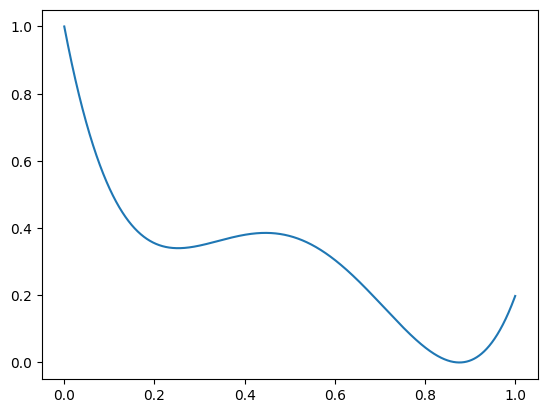

In [25]:
plt.plot(data_df['x'], data_df['y'])

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    data_df['x'].values, data_df['y'].values, test_size=0.2, random_state=42
)

# No noise XAI Benchmarck

In [27]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto'},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [28]:
# xai_benchmark.fit(data_df[['x']], data_df['y'].values)
xai_benchmark.fit(X_train.reshape(-1,1), y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [29]:
# xai_benchmark.predict(data_df[['x']], data_df['y'].values, get_metrics=True)
xai_benchmark.predict(X_test.reshape(-1,1), y_test, get_metrics=True)

({'ridge': array([0.22465081, 0.32179101, 0.50473425, ..., 0.1254662 , 0.54413551,
         0.18270953]),
  'pls': array([0.22453561, 0.32182142, 0.50503889, ..., 0.12520233, 0.54449921,
         0.18253147]),
  'decision_tree': array([0.27459417, 0.36268029, 0.36268029, ..., 0.07121389, 0.50534442,
         0.17907027]),
  'svm': array([0.21824279, 0.31085838, 0.48528047, ..., 0.12367802, 0.52284649,
         0.17825507]),
  'knn': array([0.27668958, 0.38415741, 0.37786457, ..., 0.0613229 , 0.49239231,
         0.18683249])},
 {'ridge': {'mse': 0.009103749158802096,
   'rmse': 0.09541356904970119,
   'mae': 0.0753578108524792,
   'R2': 0.7875035539572921},
  'pls': {'mse': 0.009101082255768953,
   'rmse': 0.09539959253460652,
   'mae': 0.07535820834646066,
   'R2': 0.7875658038508907},
  'decision_tree': {'mse': 0.00019886954104437291,
   'rmse': 0.014102111226492752,
   'mae': 0.011908406140477891,
   'R2': 0.9953580585360028},
  'svm': {'mse': 0.009354585367084065,
   'rmse': 0.0967

Add goussian noise to the dataframe

In [30]:
sigma = 0.05
df_noisy = add_gaussian_noise(
        df=data_df.copy(),
        columns=[x for x in data_df.columns],
        mean=0,
        std=sigma
)

In [31]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    df_noisy['x'].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

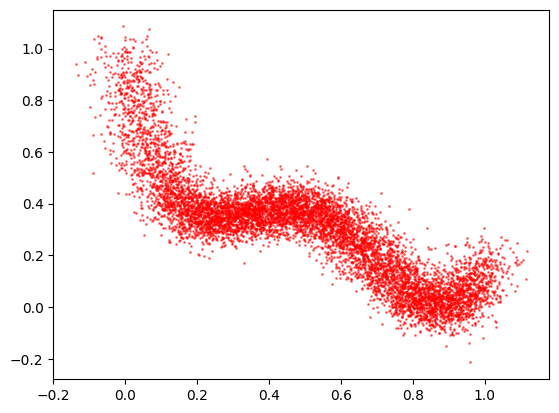

In [33]:
plt.scatter(X_train_noisy, y_train_noisy, s=1, c='r', alpha=0.5)

# Noisy XAI Benchmarck

In [32]:
xai_benchmark.fit(X_train_noisy.reshape(-1,1), y_train_noisy)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [34]:
xai_benchmark.predict(X_test_noisy.reshape(-1,1), y_test_noisy, get_metrics=True)

({'ridge': array([0.20594309, 0.28679171, 0.45172537, ..., 0.13363485, 0.50799561,
         0.19945757]),
  'pls': array([0.20580444, 0.28676994, 0.45194205, ..., 0.13339166, 0.50829363,
         0.19930954]),
  'decision_tree': array([0.23350963, 0.36610188, 0.36610188, ..., 0.07817402, 0.41079382,
         0.30390971]),
  'svm': array([0.20388545, 0.27882696, 0.43170993, ..., 0.13686033, 0.48386885,
         0.19787379]),
  'knn': array([0.20812294, 0.37054896, 0.31029852, ..., 0.13068752, 0.34834776,
         0.29607467])},
 {'ridge': {'mse': 0.012720632298139587,
   'rmse': 0.11278578056714236,
   'mae': 0.08752644285097995,
   'R2': 0.7165821116629467},
  'pls': {'mse': 0.012718771425911561,
   'rmse': 0.11277753067837389,
   'mae': 0.08753747869768705,
   'R2': 0.7166235722181276},
  'decision_tree': {'mse': 0.007710645087962975,
   'rmse': 0.08781027894251889,
   'mae': 0.06434898260464313,
   'R2': 0.8282054934591147},
  'svm': {'mse': 0.013088935047504451,
   'rmse': 0.1144068

Create Datasets for DataLoaders

# Denoise the entire noisy dataframe

In [35]:
df_denoised = pd.DataFrame()
df_denoised['x'] = df_noisy['x'].rolling(window=5, min_periods=1).mean()
df_denoised['y'] = df_noisy['y'].rolling(window=5, min_periods=1).mean()

In [36]:
df_denoised

,x,y
0,0.028135,0.972426
1,0.021277,0.979384
2,0.011592,0.985390
3,0.017886,0.984504
4,0.027506,1.002711
...,...,...
9995,0.995184,0.202582
9996,0.970494,0.203391
9997,0.972875,0.227919
9998,0.986337,0.229980


In [37]:
X_train_denoised, X_test_denoised, y_train_denoised, y_test_denoised = train_test_split(
    df_denoised['x'].values, df_denoised['y'].values, test_size=0.2, random_state=42
)

In [38]:
xai_benchmark.fit(X_train_denoised.reshape(-1,1), y_train_denoised)
xai_benchmark.predict(X_test_denoised.reshape(-1,1), y_test_denoised, get_metrics=True)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


({'ridge': array([0.22528872, 0.30855521, 0.49302449, ..., 0.10959719, 0.52094054,
         0.16825324]),
  'pls': array([0.2251746 , 0.30856456, 0.49330736, ..., 0.10931153, 0.52126481,
         0.16805455]),
  'decision_tree': array([0.2747518 , 0.37181064, 0.35649528, ..., 0.0227029 , 0.43713204,
         0.1523732 ]),
  'svm': array([0.22001387, 0.29835779, 0.47192158, ..., 0.11116182, 0.49818728,
         0.16635023]),
  'knn': array([0.28320332, 0.38354698, 0.35720105, ..., 0.04126033, 0.42599038,
         0.1653776 ])},
 {'ridge': {'mse': 0.00994137700264237,
   'rmse': 0.09970645416743276,
   'mae': 0.07831377449354403,
   'R2': 0.7722043953899196},
  'pls': {'mse': 0.009938589183806402,
   'rmse': 0.09969247305492226,
   'mae': 0.07832025028796687,
   'R2': 0.7722682751600072},
  'decision_tree': {'mse': 0.002280979374626119,
   'rmse': 0.04775959981643606,
   'mae': 0.03402154086659432,
   'R2': 0.9477338928391938},
  'svm': {'mse': 0.010260156030691853,
   'rmse': 0.10129242

In [39]:
xai_benchmark.predict(data_df['x'].values.reshape(-1,1), data_df['y'].values, get_metrics=True)

({'ridge': array([ 0.61151449,  0.61145276,  0.61139104, ..., -0.0055189 ,
         -0.00558062, -0.00564234]),
  'pls': array([ 0.61197306,  0.61191124,  0.61184943, ..., -0.00597525,
         -0.00603706, -0.00609887]),
  'decision_tree': array([0.86583542, 0.86583542, 0.86583542, ..., 0.14779171, 0.14779171,
         0.14779171]),
  'svm': array([0.58340665, 0.58334858, 0.58329051, ..., 0.00285119, 0.00279312,
         0.00273505]),
  'knn': array([0.86580436, 0.87390243, 0.86886114, ..., 0.16897603, 0.14514704,
         0.14699254])},
 {'ridge': {'mse': 0.008702179146342658,
   'rmse': 0.09328547125004331,
   'mae': 0.07383618253661767,
   'R2': 0.7883977518621981},
  'pls': {'mse': 0.008701246642002898,
   'rmse': 0.09328047299409935,
   'mae': 0.07384319391303372,
   'R2': 0.7884204266441547},
  'decision_tree': {'mse': 0.0003827468722816192,
   'rmse': 0.019563917610785915,
   'mae': 0.013906707698660174,
   'R2': 0.9906931244139531},
  'svm': {'mse': 0.00893551842601264,
   'rm